Importing Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Loding Dataset

In [2]:
df = pd.read_csv("financial_regression.csv")

In [3]:
df.columns

Index(['date', 'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close',
       'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high',
       'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low',
       'us_rates_%', 'CPI', 'usd_chf', 'eur_usd', 'GDP', 'silver open',
       'silver high', 'silver low', 'silver close', 'silver volume',
       'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close',
       'oil volume', 'oil high-low', 'platinum open', 'platinum high',
       'platinum low', 'platinum close', 'platinum volume',
       'platinum high-low', 'palladium open', 'palladium high',
       'palladium low', 'palladium close', 'palladium volume',
       'palladium high-low', 'gold open', 'gold high', 'gold low',
       'gold close', 'gold volume'],
      dtype='object')

In [4]:
gold_df = df[['date', 'gold open', 'gold high', 'gold low',
       'gold close', 'gold volume']]

In [5]:
gold_df = gold_df.dropna()

Converting date to year

In [6]:
gold_df['date'] = pd.to_datetime(gold_df['date'])
gold_df['year'] = gold_df['date'].dt.year

Defining Features(X) & Target(y)

In [7]:
X = gold_df[['year', 'gold open', 'gold high', 'gold low', 'gold volume']]
y = gold_df['gold close']

Splitting data into Train and test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Training Linear Regression

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

Predicting using LR|

In [10]:
y_pred_lr = lr.predict(X_test)

Evaluate LR

In [11]:
print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test,y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results
MAE: 0.2743549556887381
MSE: 0.14614218849261362
R2 Score: 0.9998444709475662


Training KNN regression

In [12]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsRegressor()

Predicting using KNN

In [13]:
y_pred_knn = knn.predict(X_test)

Evaluate knn

In [14]:
print("KNN Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred_knn))
print("MSE:", mean_squared_error(y_test, y_pred_knn))
print("R2 Score:", r2_score(y_test, y_pred_knn))

KNN Regression Results
MAE: 27.248061639784947
MSE: 1091.7557116967403
R2 Score: -0.1618803104073494


Predicting Future Gold price

In [15]:
future_data = pd.DataFrame({
    'year': [2025], 
    'gold open': [1900], 
    'gold high': [1950], 
    'gold low': [1880], 
    'gold volume': [20000000]
    
})

lr_future_price = lr.predict(future_data)
knn_future_price = knn.predict(future_data)

print("Future Gold Price (Linear Regression):", lr_future_price[0])
print("Future Gold Price (KNN):", knn_future_price[0])

Future Gold Price (Linear Regression): 1927.3469077901063
Future Gold Price (KNN): 140.75560000000002


In [18]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
svr = SVR(kernel='rbf', C=100, gamma=0.1)

In [22]:
svr.fit(X_train_scaled, y_train)

SVR(C=100, gamma=0.1)

In [23]:
y_pred = svr.predict(X_test_scaled)

In [24]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.3108751021399198
RMSE: 0.5357762105333231
R2 Score: 0.9996945059389146


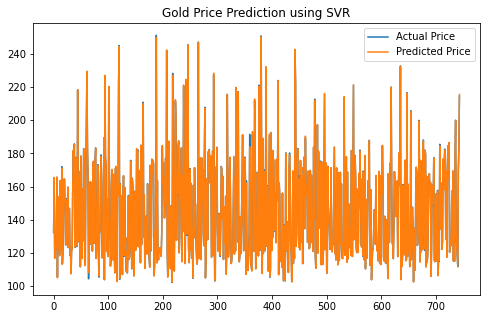

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.legend()
plt.title("Gold Price Prediction using SVR")
plt.show()